In [1]:
source("./script/map_seurat.r")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[library] tidyverse


Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.3.2 but the current version is
4.3.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

‘SeuratObject’ was built with package ‘Matrix’ 1.6.3 but the current
version is 1.6.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect




[library] Seurat



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




[library] Matrix


Loading required package: Rcpp



[library] harmony
[library] IRdisplay

> function----------------------------------------
Seurat_to_mtx

> Map_Seurat function-----------------------------
Map_Seurat_normalize
Map_Seurat_cluster
Map_Seurat_mapquery
precess_after_Seurat
run_Seurat			[simply]

> other-------------------------------------------
get_path_varmap
show_obj
savefig
Seurat_metadata_leftjoin
Seurat_gene_detect


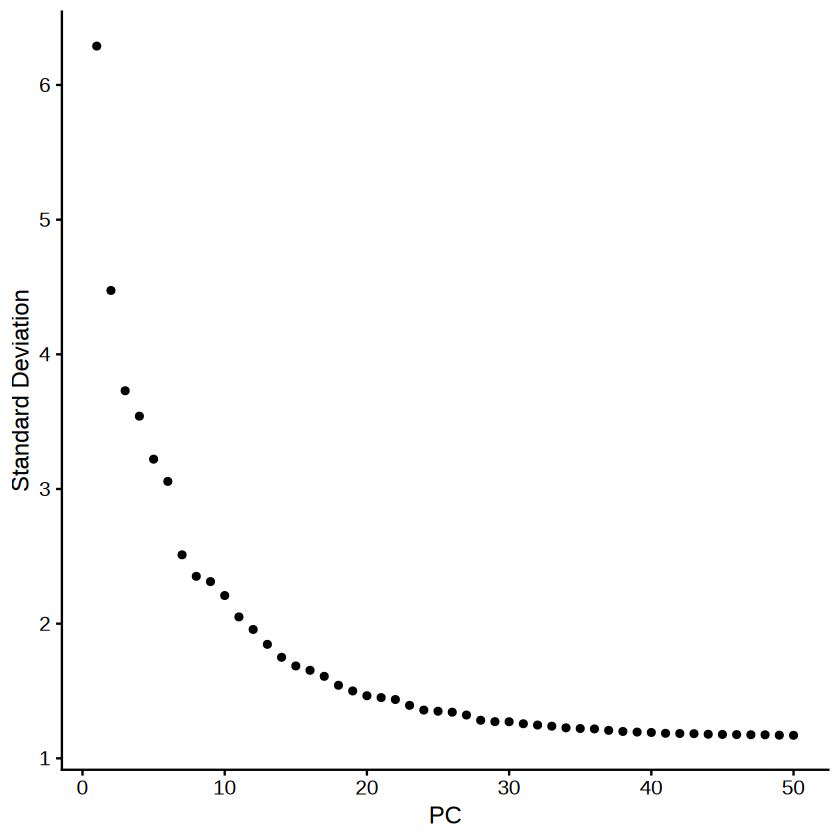

In [2]:
p_adata = "./data/mtx/MCA_Spleen"
adata = load_Seuratobj(p_adata)
adata = Map_Seurat_normalize(adata)

In [3]:
nbatch = adata@meta.data %>%
  distinct(batch) %>%
  nrow()

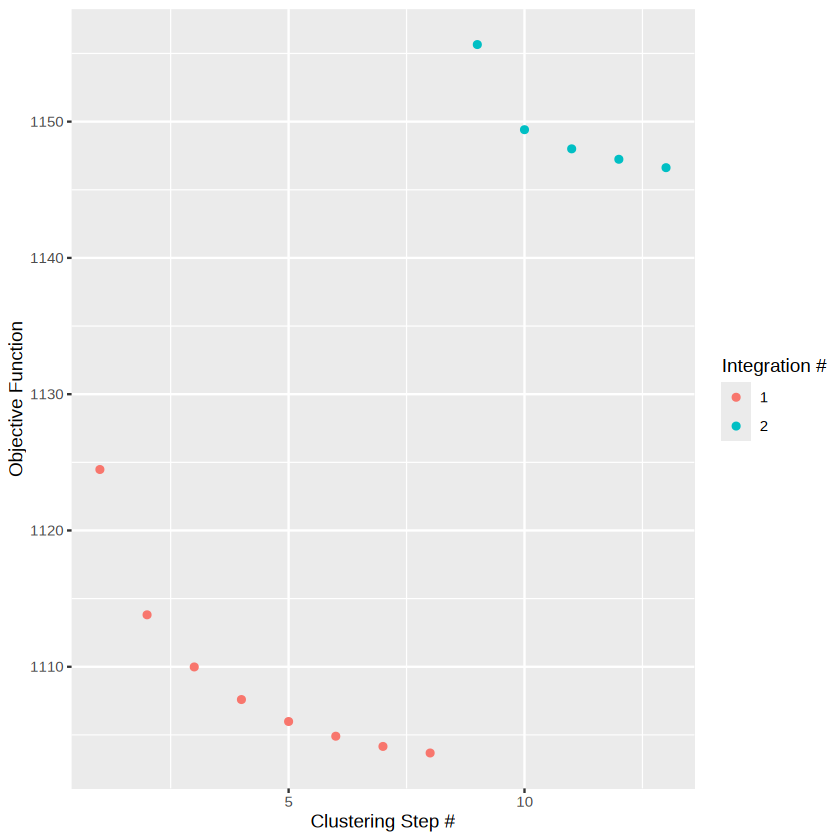

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


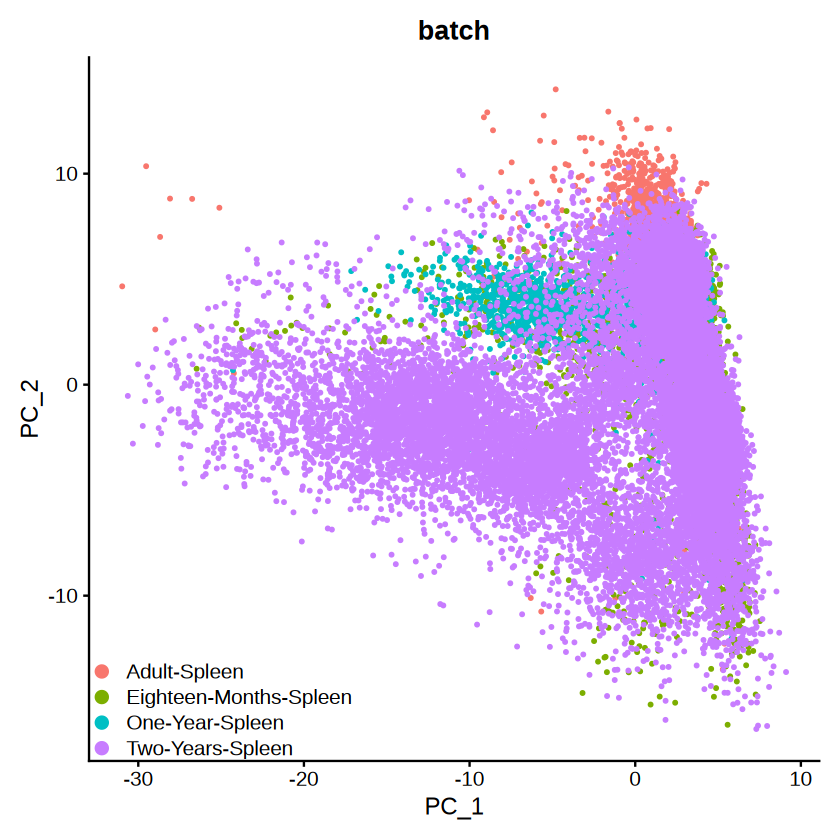

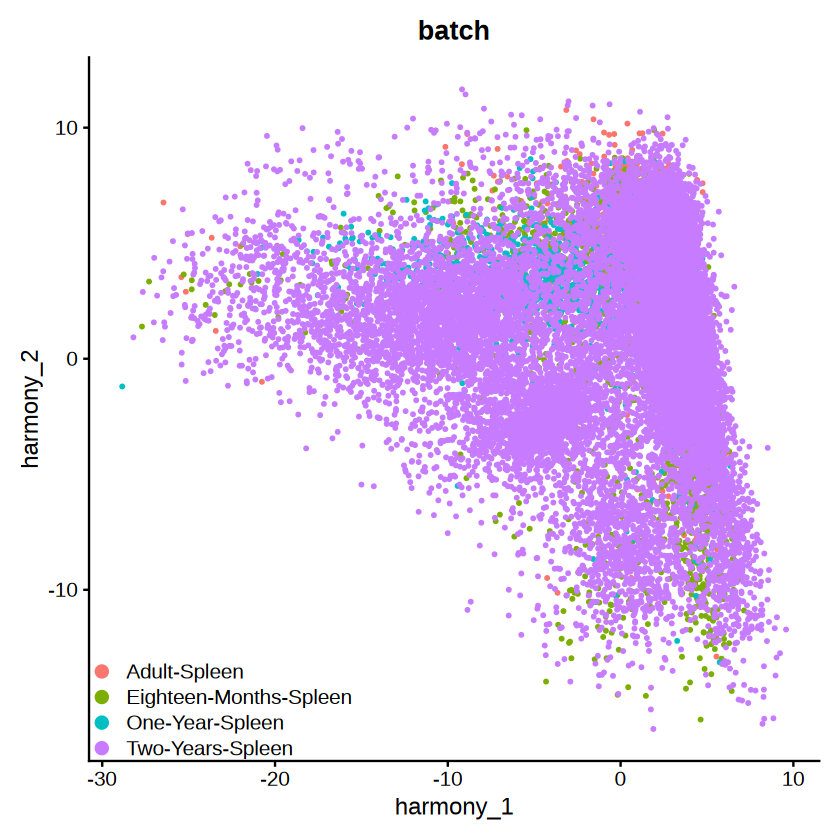

In [4]:
key_batch = "batch"
key_celltype= "cell_type"
dims = 1:20
resolution = 0.1
if(nbatch > 1){
    adata = Map_Seurat_cluster_run_harmony(
        adata, dims, resolution, key_batch, key_celltype
    )
}else{
    adata = Map_Seurat_cluster(adata,dims,resolution,key_celltype)
}

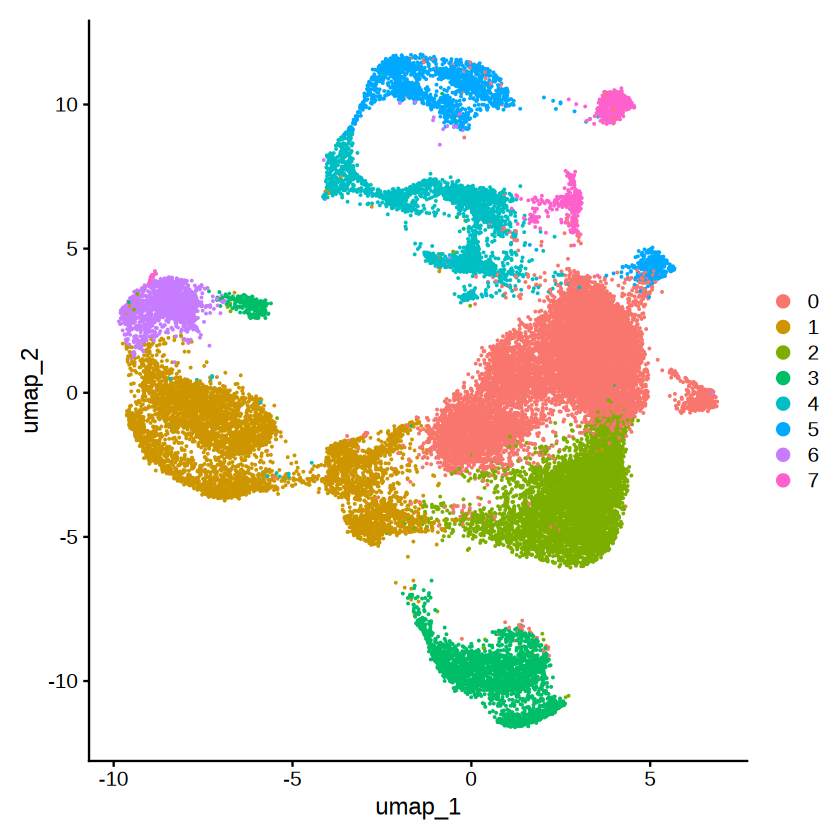

In [5]:
# DimPlot(adata, reduction = "umap")

In [16]:
p_marker = file.path(p_adata,"marker.tsv")
if(!file.exists(p_marker)){
    Idents(adata) <- "seurat_clusters"
    df_marker = FindAllMarkers(adata)
    df_marker %>%  write.table(p_marker,sep="\t")
}
df_marker = read.csv(p_marker,sep="\t",row.names = 1)
df_marker = df_marker %>% filter(
    p_val_adj < 0.05, avg_log2FC > 1, pct.1 > .4
) %>% arrange(cluster,desc(avg_log2FC))
df_marker %>% head(2)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
Baiap3,0,3.793700,0.118,0.009,0,0,Baiap3
Ccr5,0,3.332467,0.099,0.011,0,0,Ccr5


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
Ccl5,0,3.058551,0.897,0.338,0,0,Ccl5
Ms4a4b,0,2.837139,0.665,0.124,0,0,Ms4a4b


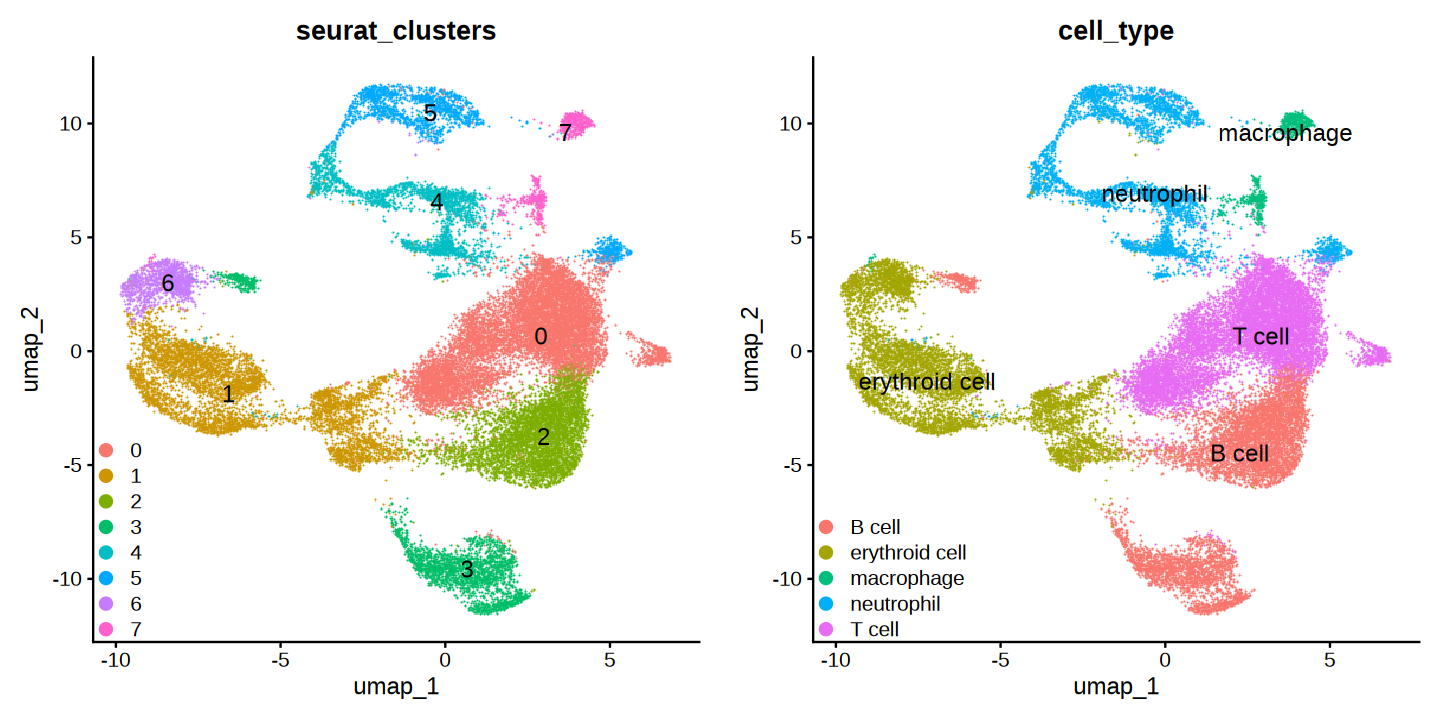

In [62]:
tbl_cell_type <- tribble(
  ~seurat_clusters,~cell_type,
    '0','T cell',
    '1','erythroid cell',
    '6','erythroid cell',
    '2',"B cell",
    '3',"B cell",
    '4','neutrophil',
    '5','neutrophil',
    '7',"macrophage",
)
adata@meta.data <- adata@meta.data %>% 
    mutate(seurat_clusters = as.character(seurat_clusters)) %>%
    select(!any_of('cell_type')) %>%
    Seurat_metadata_leftjoin(tbl_cell_type,by = 'seurat_clusters')

nrow_ = 1
ncol_ = 2
set_repr_plot_szie(ncol_,nrow_)
p1 = UMAPPlot(adata,label =TRUE,label.size = 5,pt.size=1.5,
              group.by = 'seurat_clusters',raster=TRUE) + them_legend
p2 = UMAPPlot(adata,label =TRUE,label.size = 5,pt.size=1.5,
              group.by = 'cell_type',raster=TRUE) + them_legend
p_cluster = cowplot::plot_grid(p1,p2,nrow = nrow_,ncol = ncol_)
p_cluster %>% print

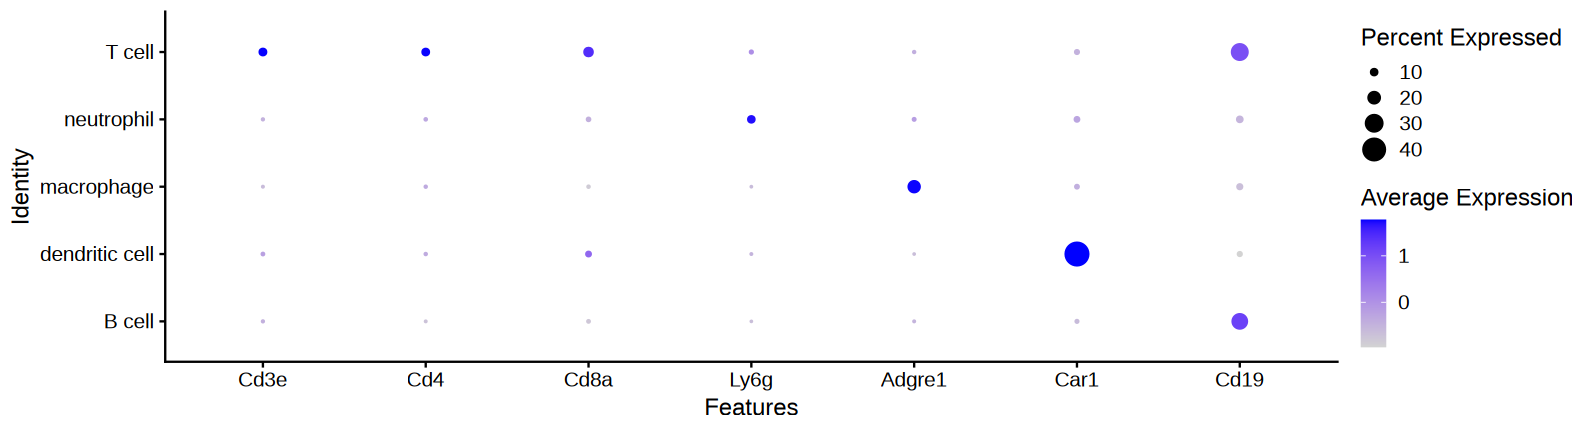

In [61]:
ncol_ <- 2.2
nrow_ <- .6
set_repr_plot_szie(ncol_,nrow_)
temp_genes = c(
    str_split("Cd3e,Cd4,Cd8a",",")[[1]],
    str_split("Ly6g",",")[[1]],
    str_split("Adgre1",",")[[1]],
    str_split("Car1",",")[[1]],
    str_split("Cd19",",")[[1]]
)
p = DotPlot(
    adata,
    temp_genes,group.by="cell_type"
)
p %>% print

In [65]:
adata@meta.data %>% write.table(file.path(p_adata,"obs.tsv"),sep="\t")